# Content-Based Movie Similarity Search

## Goal

The goal of this notebook is to build a content-based similarity search system for movies.

Given a movie title, the system retrieves movies that are similar based on plot overview, genres, keywords, cast, and crew metadata.

This project introduces the main ideas behind similarity search:

- Text representation
- TF-IDF vectors
- Cosine similarity
- Nearest-neighbour retrieval
- Dimensionality reduction
- Clustering
- Approximate retrieval intuition
- Retrieval evaluation

This notebook is not a full recommendation system yet. It focuses on the core retrieval layer: representing items as vectors and finding nearby items in vector space.

In [1]:
import os
import ast
import json
import warnings

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [2]:
path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")
print("Dataset downloaded to:", path)

print("Files:")
print(os.listdir(path))

100%|██████████| 8.89M/8.89M [00:02<00:00, 3.99MB/s]

Extracting files...


Dataset downloaded to: C:\Users\ADMIN\.cache\kagglehub\datasets\tmdb\tmdb-movie-metadata\versions\2
Files:
['tmdb_5000_credits.csv', 'tmdb_5000_movies.csv']


In [3]:
movies_path = os.path.join(path, "tmdb_5000_movies.csv")
credits_path = os.path.join(path, "tmdb_5000_credits.csv")

movies = pd.read_csv(movies_path)
credits = pd.read_csv(credits_path)

movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {""id"": 878, ""name"": ""Science Fiction""}]",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"": 2964, ""name"": ""future""}, {""id"": 3386, ""name"": ""space war""}, {""id"": 3388, ""name"": ""space colony""}, {""id"": 3679, ""name"": ""society""}, {""id"": 3801, ""name...",en,Avatar,"In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289}, {""name"": ""Twentieth Century Fox Film Corporation"", ""id"": 306}, {""name"": ""Dune Entertainment"", ""id"": 444}, {""name"": ""Lightstorm Entertainment"", ""id""...","[{""iso_3166_1"": ""US"", ""name"": ""United States of America""}, {""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""}]",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {""id"": 28, ""name"": ""Action""}]",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""name"": ""drug abuse""}, {""id"": 911, ""name"": ""exotic island""}, {""id"": 1319, ""name"": ""east india trading company""}, {""id"": 2038, ""name"": ""love of one's life...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of the Earth with Will Turner and Elizabeth Swann. But nothing is quite as it seems.",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""name"": ""Jerry Bruckheimer Films"", ""id"": 130}, {""name"": ""Second Mate Productions"", ""id"": 19936}]","[{""iso_3166_1"": ""US"", ""name"": ""United States of America""}]",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 80, ""name"": ""Crime""}]",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name"": ""based on novel""}, {""id"": 4289, ""name"": ""secret agent""}, {""id"": 9663, ""name"": ""sequel""}, {""id"": 14555, ""name"": ""mi6""}, {""id"": 156095, ""name"": ""brit...",en,Spectre,"A cryptic message from Bond’s past sends him on a trail to uncover a sinister organization. While M battles political forces to keep the secret service alive, Bond peels back the layers of deceit ...",107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""name"": ""Danjaq"", ""id"": 10761}, {""name"": ""B24"", ""id"": 69434}]","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""}, {""iso_3166_1"": ""US"", ""name"": ""United States of America""}]",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""}, {""iso_639_1"": ""en"", ""name"": ""English""}, {""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}, {""iso_639_1"": ""it"", ""name"": ""Italiano""}, {""iso_639_1"": ""de"", ""na...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""name"": ""Crime""}, {""id"": 18, ""name"": ""Drama""}, {""id"": 53, ""name"": ""Thriller""}]",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853, ""name"": ""crime fighter""}, {""id"": 949, ""name"": ""terrorist""}, {""id"": 1308, "

In [4]:
credits.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""credit_id"": ""5602a8a7c3a3685532001c9a"", ""gender"": 2, ""id"": 65731, ""name"": ""Sam Worthington"", ""order"": 0}, {""cast_id"": 3, ""character"": ""Neytiri"", ""cred...","[{""credit_id"": ""52fe48009251416c750aca23"", ""department"": ""Editing"", ""gender"": 0, ""id"": 1721, ""job"": ""Editor"", ""name"": ""Stephen E. Rivkin""}, {""credit_id"": ""539c47ecc3a36810e3001f87"", ""department"": ..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Sparrow"", ""credit_id"": ""52fe4232c3a36847f800b50d"", ""gender"": 2, ""id"": 85, ""name"": ""Johnny Depp"", ""order"": 0}, {""cast_id"": 5, ""character"": ""Will Turner"", ...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""department"": ""Camera"", ""gender"": 2, ""id"": 120, ""job"": ""Director of Photography"", ""name"": ""Dariusz Wolski""}, {""credit_id"": ""52fe4232c3a36847f800b4fd"", ""d..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""credit_id"": ""52fe4d22c3a368484e1d8d6b"", ""gender"": 2, ""id"": 8784, ""name"": ""Daniel Craig"", ""order"": 0}, {""cast_id"": 14, ""character"": ""Blofeld"", ""credit_id...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""department"": ""Sound"", ""gender"": 2, ""id"": 153, ""job"": ""Original Music Composer"", ""name"": ""Thomas Newman""}, {""credit_id"": ""52fe4d22c3a368484e1d8d77"", ""dep..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Batman"", ""credit_id"": ""52fe4781c3a36847f8139869"", ""gender"": 2, ""id"": 3894, ""name"": ""Christian Bale"", ""order"": 0}, {""cast_id"": 8, ""character"": ""Alfred Pe...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""department"": ""Sound"", ""gender"": 2, ""id"": 947, ""job"": ""Original Music Composer"", ""name"": ""Hans Zimmer""}, {""credit_id"": ""52fe4781c3a36847f8139899"", ""depar..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""credit_id"": ""52fe479ac3a36847f813ea75"", ""gender"": 2, ""id"": 60900, ""name"": ""Taylor Kitsch"", ""order"": 0}, {""cast_id"": 20, ""character"": ""Dejah Thoris"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""department"": ""Writing"", ""gender"": 2, ""id"": 7, ""job"": ""Screenplay"", ""name"": ""Andrew Stanton""}, {""credit_id"": ""52fe479ac3a36847f813ea65"", ""department"": ""D..."


## Dataset

This notebook uses the TMDB 5000 Movie Dataset from Kaggle.

The dataset contains metadata for around 5,000 movies. It includes movie information such as title, overview, genres, keywords, popularity, vote average, vote count, budget, and revenue. A separate credits file contains cast and crew information.

This project uses the metadata to build a content-based similarity search system. The goal is to retrieve movies that are similar to a query movie based on their content and descriptive features.

In [6]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [7]:
credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  4803 non-null   int64 
 1   title     4803 non-null   object
 2   cast      4803 non-null   object
 3   crew      4803 non-null   object
dtypes: int64(1), object(3)
memory usage: 150.2+ KB


## Initial Data Inspection

The movies table contains 4,803 rows and 20 columns. The credits table also contains 4,803 rows, with 4 columns.

The movies table contains several missing values. The main missing columns are `homepage`, `tagline`, `overview`, `release_date`, and `runtime`. The credits table has no missing values.

The most important content fields for this project are available for almost all movies, especially `title`, `overview`, `genres`, `keywords`, `cast`, and `crew`.

This makes the dataset suitable for similarity search because each movie has both unstructured text information and structured metadata that can be converted into searchable features.

In [8]:
credits = credits.rename(columns={"movie_id": "id"})
df = movies.merge(credits, on="id", how="left", suffixes=("", "_credits"))

print("Merged shape:", df.shape)
df.head()

Merged shape: (4803, 23)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,title_credits,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {""id"": 878, ""name"": ""Science Fiction""}]",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"": 2964, ""name"": ""future""}, {""id"": 3386, ""name"": ""space war""}, {""id"": 3388, ""name"": ""space colony""}, {""id"": 3679, ""name"": ""society""}, {""id"": 3801, ""name...",en,Avatar,"In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289}, {""name"": ""Twentieth Century Fox Film Corporation"", ""id"": 306}, {""name"": ""Dune Entertainment"", ""id"": 444}, {""name"": ""Lightstorm Entertainment"", ""id""...","[{""iso_3166_1"": ""US"", ""name"": ""United States of America""}, {""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""}]",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Released,Enter the World of Pandora.,Avatar,7.2,11800,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""credit_id"": ""5602a8a7c3a3685532001c9a"", ""gender"": 2, ""id"": 65731, ""name"": ""Sam Worthington"", ""order"": 0}, {""cast_id"": 3, ""character"": ""Neytiri"", ""cred...","[{""credit_id"": ""52fe48009251416c750aca23"", ""department"": ""Editing"", ""gender"": 0, ""id"": 1721, ""job"": ""Editor"", ""name"": ""Stephen E. Rivkin""}, {""credit_id"": ""539c47ecc3a36810e3001f87"", ""department"": ..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {""id"": 28, ""name"": ""Action""}]",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""name"": ""drug abuse""}, {""id"": 911, ""name"": ""exotic island""}, {""id"": 1319, ""name"": ""east india trading company""}, {""id"": 2038, ""name"": ""love of one's life...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of the Earth with Will Turner and Elizabeth Swann. But nothing is quite as it seems.",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""name"": ""Jerry Bruckheimer Films"", ""id"": 130}, {""name"": ""Second Mate Productions"", ""id"": 19936}]","[{""iso_3166_1"": ""US"", ""name"": ""United States of America""}]",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Sparrow"", ""credit_id"": ""52fe4232c3a36847f800b50d"", ""gender"": 2, ""id"": 85, ""name"": ""Johnny Depp"", ""order"": 0}, {""cast_id"": 5, ""character"": ""Will Turner"", ...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""department"": ""Camera"", ""gender"": 2, ""id"": 120, ""job"": ""Director of Photography"", ""name"": ""Dariusz Wolski""}, {""credit_id"": ""52fe4232c3a36847f800b4fd"", ""d..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 80, ""name"": ""Crime""}]",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name"": ""based on novel""}, {""id"": 4289, ""name"": ""secret agent""}, {""id"": 9663, ""name"": ""sequel""}, {""id"": 14555, ""name"": ""mi6""}, {""id"": 156095, ""name"": ""brit...",en,Spectre,"A cryptic message from Bond’s past sends him on a trail to uncover a sinister organization. While M battles political forces to keep 

In [9]:
[col for col in df.columns if "title" in col.lower()]

['original_title', 'title', 'title_credits']

In [10]:
if "title_credits" in df.columns:
    df = df.drop(columns=["title_credits"])

df[["id", "title", "overview", "genres", "keywords", "cast", "crew"]].head()

,id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {""id"": 878, ""name"": ""Science Fiction""}]","[{""id"": 1463, ""name"": ""culture clash""}, {""id"": 2964, ""name"": ""future""}, {""id"": 3386, ""name"": ""space war""}, {""id"": 3388, ""name"": ""space colony""}, {""id"": 3679, ""name"": ""society""}, {""id"": 3801, ""name...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""credit_id"": ""5602a8a7c3a3685532001c9a"", ""gender"": 2, ""id"": 65731, ""name"": ""Sam Worthington"", ""order"": 0}, {""cast_id"": 3, ""character"": ""Neytiri"", ""cred...","[{""credit_id"": ""52fe48009251416c750aca23"", ""department"": ""Editing"", ""gender"": 0, ""id"": 1721, ""job"": ""Editor"", ""name"": ""Stephen E. Rivkin""}, {""credit_id"": ""539c47ecc3a36810e3001f87"", ""department"": ..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of the Earth with Will Turner and Elizabeth Swann. But nothing is quite as it seems.","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {""id"": 28, ""name"": ""Action""}]","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""name"": ""drug abuse""}, {""id"": 911, ""name"": ""exotic island""}, {""id"": 1319, ""name"": ""east india trading company""}, {""id"": 2038, ""name"": ""love of one's life...","[{""cast_id"": 4, ""character"": ""Captain Jack Sparrow"", ""credit_id"": ""52fe4232c3a36847f800b50d"", ""gender"": 2, ""id"": 85, ""name"": ""Johnny Depp"", ""order"": 0}, {""cast_id"": 5, ""character"": ""Will Turner"", ...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""department"": ""Camera"", ""gender"": 2, ""id"": 120, ""job"": ""Director of Photography"", ""name"": ""Dariusz Wolski""}, {""credit_id"": ""52fe4232c3a36847f800b4fd"", ""d..."
2,206647,Spectre,"A cryptic message from Bond’s past sends him on a trail to uncover a sinister organization. While M battles political forces to keep the secret service alive, Bond peels back the layers of deceit ...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 80, ""name"": ""Crime""}]","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name"": ""based on novel""}, {""id"": 4289, ""name"": ""secret agent""}, {""id"": 9663, ""name"": ""sequel""}, {""id"": 14555, ""name"": ""mi6""}, {""id"": 156095, ""name"": ""brit...","[{""cast_id"": 1, ""character"": ""James Bond"", ""credit_id"": ""52fe4d22c3a368484e1d8d6b"", ""gender"": 2, ""id"": 8784, ""name"": ""Daniel Craig"", ""order"": 0}, {""cast_id"": 14, ""character"": ""Blofeld"", ""credit_id...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""department"": ""Sound"", ""gender"": 2, ""id"": 153, ""job"": ""Original Music Composer"", ""name"": ""Thomas Newman""}, {""credit_id"": ""52fe4d22c3a368484e1d8d77"", ""dep..."
3,49026,The Dark Knight Rises,"Following the death of District Attorney Harvey Dent, Batman assumes responsibility for Dent's crimes to protect the late attorney's reputation and is subsequently hunted by the Gotham City Police...","[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""name"": ""Crime""}, {""id"": 18, ""name"": ""Drama""}, {""id"": 53, ""name"": ""Thriller""}]","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853, ""name"": ""crime fighter""}, {""id"": 949, ""name"": ""terrorist""}, {""id"": 1308, ""name"": ""secret identity""}, {""id"": 1437, ""name"": ""burglar""}, {""id"": 3051, ""n...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Batman"", ""credit_id"": ""52fe4781c3a36847f8139869"", ""gender"": 2, ""id"": 3894, ""name"": ""Christian Bale"", ""order"": 0}, {""cast_id"": 8, ""character"": ""Alfred Pe...","[{""credit_id""

## Data Merge

The movie metadata table and credits table are merged using the movie ID.

The merged dataset contains 4,803 rows and 23 columns before removing duplicate title information. The merge successfully combines movie-level metadata with cast and crew information.

After the merge, the duplicate `title_credits` column is removed because the main movie metadata table already contains the movie title.

This produces one table where each movie has descriptive metadata, cast information, and crew information. This is useful because movie similarity can depend not only on plot summary and genre, but also on actors, directors, and keywords.

In [11]:
def parse_names(value, max_items=None):
    """
    Parse a JSON-like string containing dictionaries with a 'name' field.
    Returns a list of cleaned names.
    """
    try:
        items = ast.literal_eval(value)
        names = [item["name"] for item in items if "name" in item]
        if max_items is not None:
            names = names[:max_items]
        return names
    except:
        return []

In [12]:
def get_director(crew_value):
    """
    Extract director name from the crew column.
    """
    try:
        crew_items = ast.literal_eval(crew_value)
        directors = [item["name"] for item in crew_items if item.get("job") == "Director"]
        return directors
    except:
        return []

In [13]:
df["genre_names"] = df["genres"].apply(parse_names)
df["keyword_names"] = df["keywords"].apply(parse_names)
df["top_cast"] = df["cast"].apply(lambda x: parse_names(x, max_items=5))
df["director"] = df["crew"].apply(get_director)

df[["title", "genre_names", "keyword_names", "top_cast", "director"]].head()

,title,genre_names,keyword_names,top_cast,director
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colony, society, space travel, futuristic, romance, space, alien, tribe, alien planet, cgi, marine, soldier, battle, love affair, anti war, power relations...","[Sam Worthington, Zoe Saldana, Sigourney Weaver, Stephen Lang, Michelle Rodriguez]",[James Cameron]
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india trading company, love of one's life, traitor, shipwreck, strong woman, ship, alliance, calypso, afterlife, fighter, pirate, swashbuckler, aftercredits...","[Johnny Depp, Orlando Bloom, Keira Knightley, Stellan Skarsgård, Chow Yun-fat]",[Gore Verbinski]
2,Spectre,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi6, british secret service, united kingdom]","[Daniel Craig, Christoph Waltz, Léa Seydoux, Ralph Fiennes, Monica Bellucci]",[Sam Mendes]
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret identity, burglar, hostage drama, time bomb, gotham city, vigilante, cover-up, superhero, villainess, tragic hero, terrorism, destruction, catwoman, ca...","[Christian Bale, Michael Caine, Gary Oldman, Anne Hathaway, Tom Hardy]",[Christopher Nolan]
4,John Carter,"[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel, princess, alien, steampunk, martian, escape, edgar rice burroughs, alien race, superhuman strength, mars civilization, sword and planet, 19th centur...","[Taylor Kitsch, Lynn Collins, Samantha Morton, Willem Dafoe, Thomas Haden Church]",[Andrew Stanton]


## Parsing Metadata Fields

Several metadata columns are stored as JSON-like text, where each row contains a list of dictionaries.

For similarity search, these nested fields need to be converted into simple lists of names.

The notebook extracts:

- Genre names
- Keyword names
- Top cast members
- Director names

These fields are useful because they provide structured content signals beyond the movie overview text.

In [14]:
def clean_token(text):
    return str(text).lower().replace(" ", "")

def clean_list(items):
    return [clean_token(item) for item in items]

df["genre_tokens"] = df["genre_names"].apply(clean_list)
df["keyword_tokens"] = df["keyword_names"].apply(clean_list)
df["cast_tokens"] = df["top_cast"].apply(clean_list)
df["director_tokens"] = df["director"].apply(clean_list)

df[["title", "genre_tokens", "keyword_tokens", "cast_tokens", "director_tokens"]].head()

,title,genre_tokens,keyword_tokens,cast_tokens,director_tokens
0,Avatar,"[action, adventure, fantasy, sciencefiction]","[cultureclash, future, spacewar, spacecolony, society, spacetravel, futuristic, romance, space, alien, tribe, alienplanet, cgi, marine, soldier, battle, loveaffair, antiwar, powerrelations, mindan...","[samworthington, zoesaldana, sigourneyweaver, stephenlang, michellerodriguez]",[jamescameron]
1,Pirates of the Caribbean: At World's End,"[adventure, fantasy, action]","[ocean, drugabuse, exoticisland, eastindiatradingcompany, loveofone'slife, traitor, shipwreck, strongwoman, ship, alliance, calypso, afterlife, fighter, pirate, swashbuckler, aftercreditsstinger]","[johnnydepp, orlandobloom, keiraknightley, stellanskarsgård, chowyun-fat]",[goreverbinski]
2,Spectre,"[action, adventure, crime]","[spy, basedonnovel, secretagent, sequel, mi6, britishsecretservice, unitedkingdom]","[danielcraig, christophwaltz, léaseydoux, ralphfiennes, monicabellucci]",[sammendes]
3,The Dark Knight Rises,"[action, crime, drama, thriller]","[dccomics, crimefighter, terrorist, secretidentity, burglar, hostagedrama, timebomb, gothamcity, vigilante, cover-up, superhero, villainess, tragichero, terrorism, destruction, catwoman, catburgla...","[christianbale, michaelcaine, garyoldman, annehathaway, tomhardy]",[christophernolan]
4,John Carter,"[action, adventure, sciencefiction]","[basedonnovel, mars, medallion, spacetravel, princess, alien, steampunk, martian, escape, edgarriceburroughs, alienrace, superhumanstrength, marscivilization, swordandplanet, 19thcentury, 3d]","[taylorkitsch, lynncollins, samanthamorton, willemdafoe, thomashadenchurch]",[andrewstanton]


## Token Cleaning

Names and phrases are cleaned before vectorization.

For example, a director name such as `Christopher Nolan` is converted into `christophernolan`.

This prevents the vectorizer from treating `Christopher` and `Nolan` as separate unrelated words. The same idea is applied to actors, genres, and keywords.

## Search Text Construction

A single searchable text field is created by combining the movie overview, genres, keywords, top cast, and director.

This converts each movie into one content document.

Some fields are repeated to give them more influence in the TF-IDF representation. For example, genres, keywords, and directors are repeated because they often provide strong similarity signals.

The constructed `search_text` field has 0 empty rows, meaning every movie has at least some searchable content after preprocessing.

In [16]:
df["overview"] = df["overview"].fillna("")

df["search_text"] = (
    df["overview"] + " " +
    df["genre_tokens"].apply(lambda x: " ".join(x) + " ") * 2 +
    df["keyword_tokens"].apply(lambda x: " ".join(x) + " ") * 2 +
    df["cast_tokens"].apply(lambda x: " ".join(x) + " ") +
    df["director_tokens"].apply(lambda x: " ".join(x) + " ") * 2
)

df[["title", "search_text"]].head()

,title,search_text
0,Avatar,"In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. action adventure fan..."
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of the Earth with Will Turner and Elizabeth Swann. But nothing is quite as it seems. adventure fantasy a..."
2,Spectre,"A cryptic message from Bond’s past sends him on a trail to uncover a sinister organization. While M battles political forces to keep the secret service alive, Bond peels back the layers of deceit ..."
3,The Dark Knight Rises,"Following the death of District Attorney Harvey Dent, Batman assumes responsibility for Dent's crimes to protect the late attorney's reputation and is subsequently hunted by the Gotham City Police..."
4,John Carter,"John Carter is a war-weary, former military captain who's inexplicably transported to the mysterious and exotic planet of Barsoom (Mars) and reluctantly becomes embroiled in an epic conflict. It's..."


In [17]:
empty_search = (df["search_text"].str.strip() == "").sum()
print("Empty search_text rows:", empty_search)

Empty search_text rows: 0


## TF-IDF Vectorization

TF-IDF converts each movie's search text into a numerical vector.

The final TF-IDF matrix has shape `(4803, 12000)`, meaning 4,803 movies are represented using 12,000 text features.

Terms receive higher weight if they are frequent in a specific movie but not too common across all movies.

This is useful for similarity search because movies with similar plots, genres, keywords, cast, or directors should have similar TF-IDF vectors.

The notebook uses unigrams and bigrams, meaning the model can learn both single words and two-word phrases.

In [18]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=12000,
    ngram_range=(1, 2),
    min_df=2
)

tfidf_matrix = tfidf.fit_transform(df["search_text"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (4803, 12000)


In [19]:
df = df.reset_index(drop=True)

title_to_index = pd.Series(df.index, index=df["title"].str.lower())

print("Number of indexed titles:", len(title_to_index))

Number of indexed titles: 4803


In [20]:
duplicate_titles = df["title"].str.lower().duplicated().sum()
print("Duplicate lowercase titles:", duplicate_titles)

Duplicate lowercase titles: 3


In [21]:
title_to_indices = df.groupby(df["title"].str.lower()).indices

def find_title_matches(query, limit=10):
    query = query.lower()
    matches = df[df["title"].str.lower().str.contains(query, na=False)][["title", "release_date", "vote_average"]]
    return matches.head(limit)

find_title_matches("batman")

,title,release_date,vote_average
9,Batman v Superman: Dawn of Justice,2016-03-23,5.7
119,Batman Begins,2005-06-10,7.5
210,Batman & Robin,1997-06-20,4.2
299,Batman Forever,1995-05-31,5.2
428,Batman Returns,1992-06-19,6.6
1359,Batman,1989-06-23,7.0
3854,"Batman: The Dark Knight Returns, Part 2",2013-01-18,7.9
4267,Batman,1966-07-30,6.1


## Title Lookup

A title lookup is created so that users can search for a movie by name and retrieve its row index.

The notebook found 3 duplicate lowercase titles. This means some movie titles are repeated, possibly due to remakes or movies sharing the same name.

To handle this, the notebook uses a safer lookup method that can search partial titles and return matching movies. This makes the similarity system easier to use interactively.

## Exact Cosine Similarity Search Results

Exact TF-IDF cosine similarity produced strong results for some query movies.

For `The Dark Knight`, the system returned highly relevant Batman-related movies such as `The Dark Knight Rises`, `Batman Begins`, `Batman Returns`, `Batman Forever`, and `Batman`. This shows that the text and metadata representation successfully captured franchise, character, and genre similarity.

For `Toy Story`, the top results included `Toy Story 2`, `Toy Story 3`, `Monster House`, `Monsters, Inc.`, and `A Bug's Life`. These are mostly animation, family, comedy, or toy-related recommendations. However, some results such as `Django Unchained` are weaker and likely appear because of shared text or metadata signals.

For `Avatar`, the system returned science-fiction and alien-related movies such as `Star Trek Into Darkness`, `Aliens`, `Treasure Planet`, `Ender's Game`, `Titan A.E.`, and `Battle: Los Angeles`.

Overall, exact TF-IDF search works well when the query movie has clear franchise, genre, keyword, or plot signals. However, it can still return some noisy results when surface-level text overlap does not fully match human judgement.

In [22]:
def get_movie_index(title):
    title = title.lower()
    
    if title in title_to_indices:
        return title_to_indices[title][0]
    
    matches = df[df["title"].str.lower().str.contains(title, na=False)]
    
    if len(matches) == 0:
        raise ValueError(f"No movie found matching title: {title}")
    
    return matches.index[0]

In [26]:
def recommend_movies_exact(title, top_n=10):
    idx = get_movie_index(title)
    
    query_vector = tfidf_matrix[idx]
    similarity_scores = linear_kernel(query_vector, tfidf_matrix).flatten()
    
    # Remove query movie itself
    similarity_scores[idx] = -1
    
    top_indices = similarity_scores.argsort()[::-1][:top_n]
    
    results = df.loc[top_indices, [
        "title", "release_date", "vote_average", "vote_count", "popularity"
    ]].copy()
    
    results["similarity_score"] = similarity_scores[top_indices]
    
    return results

In [27]:
recommend_movies_exact("The Dark Knight", top_n=10)

,title,release_date,vote_average,vote_count,popularity,similarity_score
3,The Dark Knight Rises,2012-07-16,7.6,9106,112.312950,0.474311
119,Batman Begins,2005-06-10,7.5,7359,115.040024,0.464839
428,Batman Returns,1992-06-19,6.6,1673,59.113174,0.376160
3854,"Batman: The Dark Knight Returns, Part 2",2013-01-18,7.9,419,25.891466,0.267909
299,Batman Forever,1995-05-31,5.2,1498,48.205606,0.257876
1359,Batman,1989-06-23,7.0,2096,44.104469,0.238215
9,Batman v Superman: Dawn of Justice,2016-03-23,5.7,7004,155.790452,0.236051
210,Batman & Robin,1997-06-20,4.2,1418,50.073575,0.220040
813,Superman,1978-12-13,6.9,1022,48.507081,0.197768
4638,Amidst the Devil's Wings,2014-12-01,0.0,0,0.018087,0.167056


In [28]:
recommend_movies_exact("Toy Story", top_n=10)

,title,release_date,vote_average,vote_count,popularity,similarity_score
343,Toy Story 2,1999-10-30,7.3,3806,73.575118,0.428358
42,Toy Story 3,2010-06-16,7.6,4597,59.995418,0.371783
1779,The 40 Year Old Virgin,2005-08-11,6.2,1983,38.473732,0.201099
1983,Meet the Deedles,1998-03-27,4.1,19,2.353441,0.200570
533,Monster House,2006-07-21,6.3,874,36.368839,0.163360
231,"Monsters, Inc.",2001-11-01,7.5,5996,106.815545,0.156016
837,Free Birds,2013-10-30,5.7,254,14.414937,0.131889
1062,A Bug's Life,1998-11-25,6.8,2303,87.350802,0.130858
4286,The Lion of Judah,2011-06-03,5.8,2,0.165909,0.126586
287,Django Unchained,2012-12-25,7.8,10099,82.121691,0.126289


In [29]:
recommend_movies_exact("Avatar", top_n=10)

,title,release_date,vote_average,vote_count,popularity,similarity_score
47,Star Trek Into Darkness,2013-05-05,7.4,4418,78.291018,0.201706
2403,Aliens,1986-07-18,7.7,3220,67.660940,0.197484
1191,Small Soldiers,1998-07-10,6.2,511,23.088571,0.159469
3724,Falcon Rising,2014-09-05,5.5,71,6.988357,0.153443
305,Treasure Planet,2002-11-26,7.2,948,38.924136,0.151639
260,Ender's Game,2013-10-23,6.6,2303,45.948340,0.147034
539,Titan A.E.,2000-06-16,6.3,313,14.443810,0.145853
582,Battle: Los Angeles,2011-03-08,5.5,1448,49.199234,0.139747
3534,Galaxina,1980-06-06,3.3,16,2.141143,0.135830
184,Home,2015-03-18,6.8,1519,63.473086,0.134676


## Exact Cosine Similarity Search

Exact similarity search compares the query movie vector against every other movie vector.

Cosine similarity is used because it measures the angle between vectors rather than their raw size. This is useful for text data because it focuses on the direction of term importance instead of document length.

The exact search method is simple and reliable for a dataset of around 5,000 movies. However, for millions of items, comparing against every vector becomes expensive, which is why approximate nearest-neighbour methods and vector databases are often used in larger systems.

In [30]:
def search_movies_by_text(query_text, top_n=10):
    query_vector = tfidf.transform([query_text])
    similarity_scores = linear_kernel(query_vector, tfidf_matrix).flatten()
    
    top_indices = similarity_scores.argsort()[::-1][:top_n]
    
    results = df.loc[top_indices, [
        "title", "release_date", "vote_average", "vote_count", "popularity"
    ]].copy()
    
    results["similarity_score"] = similarity_scores[top_indices]
    
    return results

In [31]:
search_movies_by_text("space adventure alien planet future war", top_n=10)

,title,release_date,vote_average,vote_count,popularity,similarity_score
1319,Riddick,2013-09-02,6.2,2035,46.630062,0.358686
1198,Escape from Planet Earth,2013-02-14,5.7,332,18.142180,0.294410
778,Meet Dave,2008-07-08,5.0,371,18.676291,0.239010
838,Alien³,1992-05-22,6.2,1633,45.856409,0.227879
305,Treasure Planet,2002-11-26,7.2,948,38.924136,0.215840
1709,Space Pirate Captain Harlock,2013-09-07,6.5,356,14.726338,0.211516
2198,Lockout,2012-04-12,5.8,715,35.232278,0.201778
507,Independence Day,1996-06-25,6.7,3260,60.442593,0.201709
1201,Predators,2010-07-03,6.0,1206,47.649554,0.197331
0,Avatar,2009-12-10,7.2,11800,150.437577,0.185188


In [32]:
search_movies_by_text("animated toys friendship family adventure", top_n=10)

,title,release_date,vote_average,vote_count,popularity,similarity_score
4387,A LEGO Brickumentary,2015-07-31,6.4,55,1.631274,0.351347
744,The Lego Movie,2014-02-06,7.5,3070,59.547928,0.222662
221,Stuart Little 2,2002-07-19,5.4,613,27.990284,0.199949
1426,Valiant,2005-03-25,5.2,235,14.051852,0.185708
1950,The True Story of Puss 'n Boots,2009-04-01,3.8,7,1.684948,0.176197
343,Toy Story 2,1999-10-30,7.3,3806,73.575118,0.170818
4125,The Lost Medallion: The Adventures of Billy Stone,2013-03-01,5.6,13,2.952932,0.159472
42,Toy Story 3,2010-06-16,7.6,4597,59.995418,0.157598
3403,Alpha and Omega: The Legend of the Saw Tooth Cave,2014-07-21,6.5,4,1.874783,0.157367
40,Cars 2,2011-06-11,5.8,2033,49.986590,0.145777


In [33]:
search_movies_by_text("crime detective corruption dark city superhero", top_n=10)

,title,release_date,vote_average,vote_count,popularity,similarity_score
2818,Witness,1985-02-08,7.0,375,19.195399,0.237404
2255,The Yards,2000-04-27,6.0,97,10.150993,0.203136
4381,The Act of Killing,2012-08-31,7.5,210,8.887411,0.199712
3981,Griff the Invisible,2011-08-19,6.1,34,1.350880,0.193050
3819,Defendor,2009-09-12,6.5,195,8.453420,0.192954
122,X-Men Origins: Wolverine,2009-04-28,6.2,4021,5.954334,0.189592
1374,L.A. Confidential,1997-09-19,7.7,1310,24.860326,0.186932
4395,The Specials,2000-09-22,5.5,11,9.055447,0.178831
2240,A Most Violent Year,2014-12-30,6.5,546,37.629309,0.177285
4399,Special,2006-01-30,6.6,32,1.260314,0.175153


## Query-Based Search

The same TF-IDF vector space can also support custom text search.

Instead of selecting an existing movie title, the user can type a description such as `space adventure alien planet future war`.

The query is transformed into a TF-IDF vector using the same vectorizer, then compared against all movie vectors.

This shows how similarity search can support both item-to-item retrieval and free-text search.

In [34]:
numeric_metadata = ["popularity", "vote_average", "vote_count"]

metadata_df = df[numeric_metadata].fillna(0)

scaler = MinMaxScaler()
metadata_scaled = scaler.fit_transform(metadata_df)

metadata_scaled[:5]

array([[0.17181451, 0.72      , 0.85805701],
       [0.15884603, 0.69      , 0.32722513],
       [0.12263486, 0.63      , 0.32475276],
       [0.12827244, 0.76      , 0.66215823],
       [0.05016895, 0.61      , 0.15445026]])

In [35]:
def recommend_movies_hybrid(title, top_n=10, text_weight=0.85, metadata_weight=0.15):
    idx = get_movie_index(title)
    
    query_vector = tfidf_matrix[idx]
    text_scores = linear_kernel(query_vector, tfidf_matrix).flatten()
    
    query_meta = metadata_scaled[idx].reshape(1, -1)
    metadata_scores = cosine_similarity(query_meta, metadata_scaled).flatten()
    
    combined_scores = text_weight * text_scores + metadata_weight * metadata_scores
    
    combined_scores[idx] = -1
    
    top_indices = combined_scores.argsort()[::-1][:top_n]
    
    results = df.loc[top_indices, [
        "title", "release_date", "vote_average", "vote_count", "popularity"
    ]].copy()
    
    results["text_score"] = text_scores[top_indices]
    results["metadata_score"] = metadata_scores[top_indices]
    results["combined_score"] = combined_scores[top_indices]
    
    return results

In [64]:
recommend_movies_hybrid("12 Angry Men", top_n=10)

,title,release_date,vote_average,vote_count,popularity,text_score,metadata_score,combined_score
1107,The Juror,1996-02-02,5.5,89,3.937352,0.314940,0.982904,0.415135
2456,The Verdict,1982-12-08,7.4,131,7.980632,0.286806,0.983384,0.391293
1209,The Rainmaker,1997-11-18,6.7,235,12.229516,0.244256,0.985977,0.355514
2775,Find Me Guilty,2006-03-16,6.5,138,12.321302,0.243477,0.984410,0.354617
1156,A Time to Kill,1996-07-24,7.0,509,25.219805,0.220115,0.990876,0.335729
1194,The Lincoln Lawyer,2011-03-17,7.0,902,26.072228,0.149623,0.995329,0.276478
2483,Philadelphia,1993-12-22,7.6,988,44.301745,0.140463,0.996044,0.268801
3914,Judgment at Nuremberg,1961-12-01,7.6,155,13.338539,0.137873,0.984213,0.264824
954,The Judge,2014-10-08,7.2,1417,42.472324,0.114721,0.999097,0.247377
2926,Dead Man Walking,1995-12-29,7.3,337,15.864928,0.116373,0.987430,0.247031


In [37]:
recommend_movies_hybrid("The Dark Knight", top_n=10)

,title,release_date,vote_average,vote_count,popularity,text_score,metadata_score,combined_score
3,The Dark Knight Rises,2012-07-16,7.6,9106,112.312950,0.474311,0.993877,0.552246
119,Batman Begins,2005-06-10,7.5,7359,115.040024,0.464839,0.980567,0.542198
428,Batman Returns,1992-06-19,6.6,1673,59.113174,0.376160,0.806572,0.440722
9,Batman v Superman: Dawn of Justice,2016-03-23,5.7,7004,155.790452,0.236051,0.995000,0.349893
299,Batman Forever,1995-05-31,5.2,1498,48.205606,0.257876,0.820672,0.342295
3854,"Batman: The Dark Knight Returns, Part 2",2013-01-18,7.9,419,25.891466,0.267909,0.707300,0.333818
1359,Batman,1989-06-23,7.0,2096,44.104469,0.238215,0.821607,0.325724
210,Batman & Robin,1997-06-20,4.2,1418,50.073575,0.220040,0.841611,0.313276
813,Superman,1978-12-13,6.9,1022,48.507081,0.197768,0.758645,0.281900
1720,Kick-Ass,2010-03-22,7.1,4645,45.054936,0.159974,0.926430,0.274943


## Hybrid Similarity Search

A hybrid similarity score combines text similarity with numerical metadata similarity.

The text score compares movie content such as overview, genres, keywords, cast, and director.

The metadata score compares numerical popularity and rating-related features.

The final score is a weighted combination of both:

```text
combined score = text weight × text score + metadata weight × metadata score

## Dimensionality Reduction with TruncatedSVD

The original TF-IDF matrix has shape `(4803, 12000)`, meaning each movie is represented using 12,000 sparse text features.

TruncatedSVD reduces this representation to `(4803, 100)`, so each movie is represented using a 100-dimensional dense vector.

The 100 SVD components explain approximately 14.42% of the total variance.

This may look low, but it is common for high-dimensional text data because information is spread across many sparse terms. The reduced vectors still capture useful broad semantic patterns and can be used for nearest-neighbour search, clustering, and retrieval comparison.

In [38]:
svd = TruncatedSVD(n_components=100, random_state=42)
movie_embeddings = svd.fit_transform(tfidf_matrix)

print("Original TF-IDF shape:", tfidf_matrix.shape)
print("Reduced embedding shape:", movie_embeddings.shape)
print("Explained variance ratio sum:", svd.explained_variance_ratio_.sum())

Original TF-IDF shape: (4803, 12000)
Reduced embedding shape: (4803, 100)
Explained variance ratio sum: 0.14420627633295321


In [39]:
nn_model = NearestNeighbors(
    n_neighbors=11,
    metric="cosine",
    algorithm="brute"
)

nn_model.fit(movie_embeddings)

,n_neighbors,11
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [40]:
def recommend_movies_svd(title, top_n=10):
    idx = get_movie_index(title)
    
    query_embedding = movie_embeddings[idx].reshape(1, -1)
    
    distances, indices = nn_model.kneighbors(query_embedding, n_neighbors=top_n + 1)
    
    distances = distances.flatten()
    indices = indices.flatten()
    
    # Remove the query movie itself
    result_indices = indices[indices != idx][:top_n]
    result_distances = distances[indices != idx][:top_n]
    
    results = df.loc[result_indices, [
        "title", "release_date", "vote_average", "vote_count", "popularity"
    ]].copy()
    
    results["cosine_distance"] = result_distances
    results["similarity_score"] = 1 - result_distances
    
    return results

In [41]:
recommend_movies_svd("The Dark Knight", top_n=10)

,title,release_date,vote_average,vote_count,popularity,cosine_distance,similarity_score
119,Batman Begins,2005-06-10,7.5,7359,115.040024,0.077728,0.922272
210,Batman & Robin,1997-06-20,4.2,1418,50.073575,0.119352,0.880648
3,The Dark Knight Rises,2012-07-16,7.6,9106,112.312950,0.152568,0.847432
299,Batman Forever,1995-05-31,5.2,1498,48.205606,0.166208,0.833792
1359,Batman,1989-06-23,7.0,2096,44.104469,0.203337,0.796663
428,Batman Returns,1992-06-19,6.6,1673,59.113174,0.213426,0.786574
9,Batman v Superman: Dawn of Justice,2016-03-23,5.7,7004,155.790452,0.310852,0.689148
813,Superman,1978-12-13,6.9,1022,48.507081,0.317017,0.682983
3854,"Batman: The Dark Knight Returns, Part 2",2013-01-18,7.9,419,25.891466,0.369323,0.630677
1720,Kick-Ass,2010-03-22,7.1,4645,45.054936,0.370676,0.629324


In [42]:
recommend_movies_svd("Toy Story", top_n=10)

,title,release_date,vote_average,vote_count,popularity,cosine_distance,similarity_score
343,Toy Story 2,1999-10-30,7.3,3806,73.575118,0.170777,0.829223
347,Cloudy with a Chance of Meatballs,2009-09-17,6.5,1747,46.781182,0.241114,0.758886
1983,Meet the Deedles,1998-03-27,4.1,19,2.353441,0.255831,0.744169
934,Curious George,2006-02-10,6.2,106,9.894346,0.276689,0.723311
926,Garfield,2004-06-10,5.2,820,17.667826,0.277789,0.722211
221,Stuart Little 2,2002-07-19,5.4,613,27.990284,0.288093,0.711907
481,Looney Tunes: Back in Action,2003-11-14,5.6,297,16.715631,0.290476,0.709524
896,Barnyard,2006-08-04,5.3,225,10.430832,0.293352,0.706648
318,Surf's Up,2007-06-08,5.9,601,23.230851,0.293694,0.706306
744,The Lego Movie,2014-02-06,7.5,3070,59.547928,0.295779,0.704221


In [43]:
recommend_movies_svd("Avatar", top_n=10)

,title,release_date,vote_average,vote_count,popularity,cosine_distance,similarity_score
507,Independence Day,1996-06-25,6.7,3260,60.442593,0.212388,0.787612
36,Transformers: Age of Extinction,2014-06-25,5.8,3095,116.840296,0.238632,0.761368
577,AVP: Alien vs. Predator,2004-08-12,5.5,1217,42.957216,0.264713,0.735287
4,John Carter,2012-03-07,6.1,2124,43.926995,0.280734,0.719266
3405,Stargate: The Ark of Truth,2008-03-11,6.9,140,8.591387,0.281530,0.718470
2327,Predator,1987-06-11,7.3,2093,50.009408,0.281737,0.718263
61,Jupiter Ascending,2015-02-04,5.2,2768,85.369080,0.286242,0.713758
91,Independence Day: Resurgence,2016-06-22,4.9,2491,48.775723,0.288912,0.711088
150,Men in Black II,2002-07-03,6.0,3114,91.332849,0.302206,0.697794
3158,Alien,1979-05-25,7.9,4470,94.184658,0.309475,0.690525


## Nearest-Neighbour Search on Reduced Vectors

After reducing the TF-IDF vectors with TruncatedSVD, each movie is represented by a smaller dense vector.

Nearest-neighbour search is then used to retrieve movies with the smallest cosine distance to the query movie.

This is closer to how modern embedding-based retrieval works, where each item is represented as a dense vector and similar items are retrieved from vector space.

In this notebook, the nearest-neighbour search still uses brute force because the dataset is small. However, the same idea can later be extended to approximate nearest-neighbour libraries or vector databases.

In [44]:
def compare_retrieval_methods(title, top_n=10):
    exact = recommend_movies_exact(title, top_n=top_n)
    svd_results = recommend_movies_svd(title, top_n=top_n)
    
    exact_titles = set(exact["title"])
    svd_titles = set(svd_results["title"])
    
    overlap = exact_titles.intersection(svd_titles)
    
    print(f"Query movie: {title}")
    print(f"Overlap count: {len(overlap)} out of {top_n}")
    print("Overlapping titles:")
    print(sorted(overlap))
    
    return exact, svd_results

exact_dark_knight, svd_dark_knight = compare_retrieval_methods("The Dark Knight")

Query movie: The Dark Knight
Overlap count: 9 out of 10
Overlapping titles:
['Batman', 'Batman & Robin', 'Batman Begins', 'Batman Forever', 'Batman Returns', 'Batman v Superman: Dawn of Justice', 'Batman: The Dark Knight Returns, Part 2', 'Superman', 'The Dark Knight Rises']


In [45]:
exact_toy_story, svd_toy_story = compare_retrieval_methods("Toy Story")

Query movie: Toy Story
Overlap count: 2 out of 10
Overlapping titles:
['Meet the Deedles', 'Toy Story 2']


In [46]:
exact_avatar, svd_avatar = compare_retrieval_methods("Avatar")

Query movie: Avatar
Overlap count: 0 out of 10
Overlapping titles:
[]


## Comparing Exact and Reduced-Vector Retrieval

Exact TF-IDF search uses the full sparse vector representation, while SVD retrieval uses a compressed 100-dimensional dense representation.

The overlap between the two methods varied heavily by query movie.

For `The Dark Knight`, the overlap was 9 out of 10 results. This means the SVD representation preserved the same Batman/superhero neighbourhood very well.

For `Toy Story`, the overlap was only 2 out of 10 results. This means SVD changed the retrieval behaviour and returned a broader set of animated or family-oriented movies rather than closely matching the exact TF-IDF ranking.

For `Avatar`, the overlap was 0 out of 10 results. The exact method returned movies such as `Star Trek Into Darkness`, `Aliens`, and `Treasure Planet`, while the SVD method returned movies such as `Independence Day`, `Transformers: Age of Extinction`, `AVP: Alien vs. Predator`, and `John Carter`.

This shows that dimensionality reduction can preserve broad semantic neighbourhoods, but it may lose specific keyword-level detail. The SVD method is more compressed and embedding-like, while exact TF-IDF is more sensitive to direct text and metadata overlap.

In [47]:
cluster_range = range(5, 21, 5)

cluster_scores = []

for k in cluster_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(movie_embeddings)
    
    score = silhouette_score(movie_embeddings, labels_temp)
    
    cluster_scores.append({
        "k": k,
        "silhouette_score": score
    })

cluster_scores_df = pd.DataFrame(cluster_scores)
cluster_scores_df

,k,silhouette_score
0,5,0.035243
1,10,0.053426
2,15,0.061195
3,20,0.072354


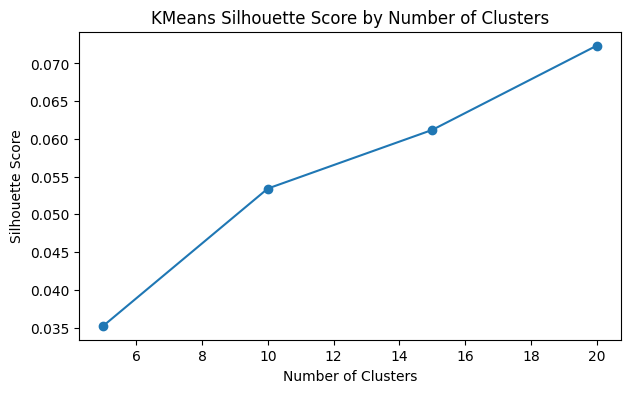

In [48]:
plt.figure(figsize=(7, 4))
plt.plot(cluster_scores_df["k"], cluster_scores_df["silhouette_score"], marker="o")
plt.title("KMeans Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

In [49]:
best_k = cluster_scores_df.sort_values("silhouette_score", ascending=False).iloc[0]["k"]
best_k = int(best_k)

print("Best k by silhouette:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(movie_embeddings)

df[["title", "genre_names", "cluster"]].head()

Best k by silhouette: 20


,title,genre_names,cluster
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]",18
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]",7
2,Spectre,"[Action, Adventure, Crime]",7
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]",4
4,John Carter,"[Action, Adventure, Science Fiction]",18


In [50]:
def inspect_cluster(cluster_id, n=10):
    cluster_movies = df[df["cluster"] == cluster_id].copy()
    
    display(
        cluster_movies[[
            "title", "release_date", "vote_average", "vote_count", "popularity", "genre_names"
        ]].sort_values("popularity", ascending=False).head(n)
    )
    
    print("Cluster size:", len(cluster_movies))

In [51]:
for cluster_id in sorted(df["cluster"].unique())[:5]:
    print("=" * 80)
    print("Cluster:", cluster_id)
    inspect_cluster(cluster_id, n=8)

Cluster: 0


,title,release_date,vote_average,vote_count,popularity,genre_names
693,Gone Girl,2014-10-01,7.9,5862,143.041543,"[Mystery, Thriller, Drama]"
694,The Bourne Identity,2002-06-14,7.3,3583,86.476817,"[Action, Drama, Mystery, Thriller]"
1553,Se7en,1995-09-22,8.1,5765,79.579532,"[Crime, Mystery, Thriller]"
982,Run All Night,2015-03-11,6.3,1148,74.646530,"[Action, Crime, Drama, Mystery, Thriller]"
1196,The Prestige,2006-10-19,8.0,4391,74.440708,"[Drama, Mystery, Thriller]"
1145,The Sixth Sense,1999-08-06,7.7,3147,73.085576,"[Mystery, Thriller, Drama]"
684,The Hateful Eight,2015-12-25,7.6,4274,68.717016,"[Crime, Drama, Mystery, Western]"
128,Angels & Demons,2009-05-13,6.5,2129,67.447636,"[Thriller, Mystery]"


Cluster size: 207
Cluster: 1


,title,release_date,vote_average,vote_count,popularity,genre_names
2522,The Imitation Game,2014-11-14,8.0,5723,145.364591,"[History, Drama, Thriller, War]"
456,Fury,2014-10-15,7.4,3946,139.575085,"[War, Drama, Action]"
1818,Schindler's List,1993-11-29,8.3,4329,104.469351,"[Drama, History, War]"
2105,12 Years a Slave,2013-10-18,7.9,3674,95.922900,"[Drama, History]"
790,American Sniper,2014-12-11,7.4,4469,87.534370,"[War, Action]"
628,Saving Private Ryan,1998-07-24,7.9,5048,76.041867,"[Drama, History, War]"
556,Braveheart,1995-05-24,7.7,3336,60.722162,"[Action, Drama, History, War]"
3571,Dallas Buyers Club,2013-09-07,7.9,2886,59.454473,"[Drama, History]"


Cluster size: 184
Cluster: 2


,title,release_date,vote_average,vote_count,popularity,genre_names
4074,It Follows,2015-02-04,6.6,1832,100.876794,"[Horror, Thriller]"
2170,Psycho,1960-06-16,8.2,2320,93.067866,"[Drama, Horror, Thriller]"
3169,The Purge: Anarchy,2014-07-17,6.6,1954,82.975841,"[Horror, Thriller]"
2284,The Shining,1980-05-22,8.1,3757,78.699993,"[Horror, Thriller]"
1605,The Cabin in the Woods,2012-04-12,6.5,2263,73.987775,"[Horror, Thriller]"
4224,Insidious,2010-09-13,6.8,1737,58.594852,"[Horror, Thriller]"
3895,The Purge,2013-05-31,6.0,2428,54.403033,"[Science Fiction, Horror, Thriller]"
2980,The Purge: Election Year,2016-06-29,6.1,1306,53.727146,"[Action, Horror, Thriller]"


Cluster size: 189
Cluster: 3


,title,release_date,vote_average,vote_count,popularity,genre_names
1160,The Conjuring 2,2016-05-13,7.0,1949,68.794673,[Horror]
864,Blade II,2002-03-22,6.2,1528,67.169587,"[Fantasy, Horror, Action, Thriller]"
589,Dracula Untold,2014-10-01,6.2,2389,64.457947,"[Horror, Action, Drama, Fantasy, War]"
1613,Carrie,2013-10-16,5.8,1463,63.848541,"[Drama, Horror]"
4291,Saw,2004-10-01,7.2,2184,63.655973,"[Horror, Mystery, Crime]"
3418,Annabelle,2014-10-02,5.6,1517,60.225219,[Horror]
597,Underworld: Awakening,2012-01-19,6.1,1862,58.401204,"[Fantasy, Action, Horror]"
1988,Zombieland,2009-10-07,7.2,3550,57.300674,"[Comedy, Horror]"


Cluster size: 240
Cluster: 4


,title,release_date,vote_average,vote_count,popularity,genre_names
3337,The Godfather,1972-03-14,8.4,5893,143.659698,"[Drama, Crime]"
1881,The Shawshank Redemption,1994-09-23,8.5,8205,136.747729,"[Drama, Crime]"
3,The Dark Knight Rises,2012-07-16,7.6,9106,112.312950,"[Action, Crime, Drama, Thriller]"
2731,The Godfather: Part II,1974-12-20,8.3,3338,105.792936,"[Drama, Crime]"
1340,We're the Millers,2013-08-07,6.8,2972,100.348805,"[Comedy, Crime]"
298,The Wolf of Wall Street,2013-12-25,7.9,6571,95.007934,"[Crime, Drama, Comedy]"
3234,Nightcrawler,2014-10-23,7.6,3395,89.095538,"[Crime, Drama, Thriller]"
1051,Prisoners,2013-09-18,7.9,3085,88.496873,"[Drama, Thriller, Crime]"


Cluster size: 236


## Clustering Movie Embeddings

KMeans clustering groups movies based on their reduced SVD vector representations.

The silhouette scores increased as the number of clusters increased:

- k = 5: 0.0352
- k = 10: 0.0534
- k = 15: 0.0612
- k = 20: 0.0724

The best value among the tested options was k = 20.

The silhouette scores are quite low overall, which means the movie clusters are not strongly separated. This is expected because movies often overlap across genres, themes, actors, and plot styles.

However, the inspected clusters still show meaningful patterns. For example, one cluster contained mystery and thriller films such as `Gone Girl`, `Se7en`, and `The Prestige`. Another cluster contained war and historical drama films such as `The Imitation Game`, `Schindler's List`, and `Saving Private Ryan`. Other clusters captured horror, crime drama, and superhero/crime-related movies.

This shows that clustering is useful for broad content grouping, even if the boundaries between movie types are not perfectly clean.

In [52]:
def recommend_movies_cluster_filtered(title, top_n=10):
    idx = get_movie_index(title)
    query_cluster = df.loc[idx, "cluster"]
    
    query_vector = tfidf_matrix[idx]
    similarity_scores = linear_kernel(query_vector, tfidf_matrix).flatten()
    
    same_cluster_mask = df["cluster"].values == query_cluster
    
    # Remove movies outside the same cluster
    filtered_scores = similarity_scores.copy()
    filtered_scores[~same_cluster_mask] = -1
    filtered_scores[idx] = -1
    
    top_indices = filtered_scores.argsort()[::-1][:top_n]
    
    results = df.loc[top_indices, [
        "title", "release_date", "vote_average", "vote_count", "popularity", "cluster"
    ]].copy()
    
    results["similarity_score"] = filtered_scores[top_indices]
    
    return results

In [53]:
recommend_movies_cluster_filtered("The Dark Knight", top_n=10)

,title,release_date,vote_average,vote_count,popularity,cluster,similarity_score
119,Batman Begins,2005-06-10,7.5,7359,115.040024,19,0.464839
428,Batman Returns,1992-06-19,6.6,1673,59.113174,19,0.376160
1359,Batman,1989-06-23,7.0,2096,44.104469,19,0.238215
9,Batman v Superman: Dawn of Justice,2016-03-23,5.7,7004,155.790452,19,0.236051
210,Batman & Robin,1997-06-20,4.2,1418,50.073575,19,0.220040
813,Superman,1978-12-13,6.9,1022,48.507081,19,0.197768
1740,Kick-Ass 2,2013-07-17,6.3,2224,40.286350,19,0.145313
870,Superman II,1980-12-04,6.5,629,30.515175,19,0.142954
14,Man of Steel,2013-06-12,6.5,6359,99.398009,19,0.131552
10,Superman Returns,2006-06-28,5.4,1400,57.925623,19,0.122930


In [54]:
recommend_movies_cluster_filtered("Toy Story", top_n=10)

,title,release_date,vote_average,vote_count,popularity,cluster,similarity_score
343,Toy Story 2,1999-10-30,7.3,3806,73.575118,14,0.428358
42,Toy Story 3,2010-06-16,7.6,4597,59.995418,14,0.371783
1983,Meet the Deedles,1998-03-27,4.1,19,2.353441,14,0.200570
533,Monster House,2006-07-21,6.3,874,36.368839,14,0.163360
231,"Monsters, Inc.",2001-11-01,7.5,5996,106.815545,14,0.156016
837,Free Birds,2013-10-30,5.7,254,14.414937,14,0.131889
1062,A Bug's Life,1998-11-25,6.8,2303,87.350802,14,0.130858
4286,The Lion of Judah,2011-06-03,5.8,2,0.165909,14,0.126586
742,The Boxtrolls,2014-09-10,6.6,668,30.656345,14,0.122816
459,Spirit: Stallion of the Cimarron,2002-05-24,7.4,831,41.670544,14,0.121973


In [55]:
recommend_movies_cluster_filtered("Avatar", top_n=10)

,title,release_date,vote_average,vote_count,popularity,cluster,similarity_score
47,Star Trek Into Darkness,2013-05-05,7.4,4418,78.291018,18,0.201706
2403,Aliens,1986-07-18,7.7,3220,67.660940,18,0.197484
260,Ender's Game,2013-10-23,6.6,2303,45.948340,18,0.147034
582,Battle: Los Angeles,2011-03-08,5.5,1448,49.199234,18,0.139747
3534,Galaxina,1980-06-06,3.3,16,2.141143,18,0.135830
1201,Predators,2010-07-03,6.0,1206,47.649554,18,0.132433
838,Alien³,1992-05-22,6.2,1633,45.856409,18,0.132075
3730,Cargo,2009-09-24,5.9,140,10.142218,18,0.131490
4,John Carter,2012-03-07,6.1,2124,43.926995,18,0.122228
778,Meet Dave,2008-07-08,5.0,371,18.676291,18,0.120151


## Cluster-Aware Recommendations

Cluster-aware recommendation first identifies the query movie's cluster, then retrieves similar movies only from that same cluster.

This can make recommendations more focused because it prevents the system from returning movies that are textually similar in small ways but belong to a very different broad content group.

However, cluster filtering can also be too restrictive. If the clustering is imperfect, useful recommendations outside the query cluster may be removed.

In [56]:
def genre_overlap_score(query_genres, result_genres):
    query_set = set(query_genres)
    result_set = set(result_genres)
    
    if len(query_set) == 0 or len(result_set) == 0:
        return 0
    
    return len(query_set.intersection(result_set)) / len(query_set.union(result_set))

In [57]:
def evaluate_recommendations_by_genre(title, recommender_func, top_n=10):
    idx = get_movie_index(title)
    query_genres = df.loc[idx, "genre_names"]
    
    results = recommender_func(title, top_n=top_n).copy()
    
    result_indices = results.index
    
    scores = []
    for result_idx in result_indices:
        result_genres = df.loc[result_idx, "genre_names"]
        scores.append(genre_overlap_score(query_genres, result_genres))
    
    results["genre_overlap"] = scores
    
    return {
        "query_title": df.loc[idx, "title"],
        "query_genres": query_genres,
        "average_genre_overlap": np.mean(scores),
        "results": results
    }

In [58]:
eval_exact_dark = evaluate_recommendations_by_genre("The Dark Knight", recommend_movies_exact)
eval_svd_dark = evaluate_recommendations_by_genre("The Dark Knight", recommend_movies_svd)
eval_cluster_dark = evaluate_recommendations_by_genre("The Dark Knight", recommend_movies_cluster_filtered)

print("Exact average genre overlap:", eval_exact_dark["average_genre_overlap"])
print("SVD average genre overlap:", eval_svd_dark["average_genre_overlap"])
print("Cluster-filtered average genre overlap:", eval_cluster_dark["average_genre_overlap"])

Exact average genre overlap: 0.42095238095238086
SVD average genre overlap: 0.39595238095238094
Cluster-filtered average genre overlap: 0.26880952380952383


In [59]:
query_movies = [
    "The Dark Knight",
    "Toy Story",
    "Avatar",
    "Titanic",
    "Iron Man",
    "The Godfather",
    "Finding Nemo",
    "Inception"
]

evaluation_rows = []

for title in query_movies:
    for method_name, recommender in [
        ("Exact TF-IDF", recommend_movies_exact),
        ("SVD NearestNeighbors", recommend_movies_svd),
        ("Cluster-filtered", recommend_movies_cluster_filtered),
    ]:
        try:
            eval_result = evaluate_recommendations_by_genre(title, recommender)
            evaluation_rows.append({
                "Query": title,
                "Method": method_name,
                "Average Genre Overlap": eval_result["average_genre_overlap"]
            })
        except Exception as e:
            print("Error:", title, method_name, e)

genre_eval_df = pd.DataFrame(evaluation_rows)
genre_eval_df

,Query,Method,Average Genre Overlap
0,The Dark Knight,Exact TF-IDF,0.420952
1,The Dark Knight,SVD NearestNeighbors,0.395952
2,The Dark Knight,Cluster-filtered,0.268810
3,Toy Story,Exact TF-IDF,0.750000
4,Toy Story,SVD NearestNeighbors,0.910000
5,Toy Story,Cluster-filtered,0.860000
6,Avatar,Exact TF-IDF,0.511905
7,Avatar,SVD NearestNeighbors,0.678333
8,Avatar,Cluster-filtered,0.478333
9,Titanic,Exact TF-IDF,0.376667


In [60]:
genre_eval_summary = genre_eval_df.groupby("Method")["Average Genre Overlap"].mean().sort_values(ascending=False)
genre_eval_summary

Method
SVD NearestNeighbors    0.711994
Cluster-filtered        0.647351
Exact TF-IDF            0.627292
Name: Average Genre Overlap, dtype: float64

## Retrieval Evaluation with Genre Overlap

Similarity search does not always have a clear correct answer. Unlike supervised learning, there is usually no single true label for what the best recommendation should be.

To create a lightweight evaluation method, this notebook measures genre overlap between the query movie and the retrieved movies.

Across the tested query movies, the average genre overlap scores were:

- SVD NearestNeighbors: 0.7120
- Cluster-filtered: 0.6474
- Exact TF-IDF: 0.6273

Based on this metric, the SVD nearest-neighbour method performed best overall.

However, the best method varied by query. For example, exact TF-IDF performed very well for `Iron Man`, while SVD performed strongly for `Toy Story`, `Avatar`, `The Godfather`, and `Inception`. Cluster-filtered retrieval worked well for `Titanic` and matched exact TF-IDF for `Iron Man`.

This shows that no single retrieval method is always best. Exact TF-IDF can capture direct keyword and metadata overlap, SVD can capture broader semantic similarity, and cluster filtering can make results more focused when the cluster is meaningful.

Genre overlap is not a perfect evaluation metric because movies can be similar in plot, tone, cast, or director even if their genres differ. However, it gives a useful quantitative signal for comparing retrieval methods.

In [61]:
def show_recommendation_details(title, recommender_func, top_n=10):
    idx = get_movie_index(title)
    query_row = df.loc[idx]
    
    print("Query Movie:")
    print("Title:", query_row["title"])
    print("Genres:", query_row["genre_names"])
    print("Overview:", query_row["overview"])
    
    results = recommender_func(title, top_n=top_n)
    
    display(results)
    
    for result_idx in results.index[:3]:
        print("=" * 80)
        print("Recommended:", df.loc[result_idx, "title"])
        print("Genres:", df.loc[result_idx, "genre_names"])
        print("Overview:", df.loc[result_idx, "overview"])

In [62]:
show_recommendation_details("Avatar", recommend_movies_exact)

Query Movie:
Title: Avatar
Genres: ['Action', 'Adventure', 'Fantasy', 'Science Fiction']
Overview: In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.


,title,release_date,vote_average,vote_count,popularity,similarity_score
47,Star Trek Into Darkness,2013-05-05,7.4,4418,78.291018,0.201706
2403,Aliens,1986-07-18,7.7,3220,67.660940,0.197484
1191,Small Soldiers,1998-07-10,6.2,511,23.088571,0.159469
3724,Falcon Rising,2014-09-05,5.5,71,6.988357,0.153443
305,Treasure Planet,2002-11-26,7.2,948,38.924136,0.151639
260,Ender's Game,2013-10-23,6.6,2303,45.948340,0.147034
539,Titan A.E.,2000-06-16,6.3,313,14.443810,0.145853
582,Battle: Los Angeles,2011-03-08,5.5,1448,49.199234,0.139747
3534,Galaxina,1980-06-06,3.3,16,2.141143,0.135830
184,Home,2015-03-18,6.8,1519,63.473086,0.134676


Recommended: Star Trek Into Darkness
Genres: ['Action', 'Adventure', 'Science Fiction']
Overview: When the crew of the Enterprise is called back home, they find an unstoppable force of terror from within their own organization has detonated the fleet and everything it stands for, leaving our world in a state of crisis.  With a personal score to settle, Captain Kirk leads a manhunt to a war-zone world to capture a one man weapon of mass destruction. As our heroes are propelled into an epic chess game of life and death, love will be challenged, friendships will be torn apart, and sacrifices must be made for the only family Kirk has left: his crew.
Recommended: Aliens
Genres: ['Horror', 'Action', 'Thriller', 'Science Fiction']
Overview: When Ripley's lifepod is found by a salvage crew over 50 years later, she finds that terra-formers are on the very planet they found the alien species. When the company sends a family of colonists out to investigate her story, all contact is lost with the 

In [63]:
show_recommendation_details("Toy Story", recommend_movies_svd)

Query Movie:
Title: Toy Story
Genres: ['Animation', 'Comedy', 'Family']
Overview: Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.


,title,release_date,vote_average,vote_count,popularity,cosine_distance,similarity_score
343,Toy Story 2,1999-10-30,7.3,3806,73.575118,0.170777,0.829223
347,Cloudy with a Chance of Meatballs,2009-09-17,6.5,1747,46.781182,0.241114,0.758886
1983,Meet the Deedles,1998-03-27,4.1,19,2.353441,0.255831,0.744169
934,Curious George,2006-02-10,6.2,106,9.894346,0.276689,0.723311
926,Garfield,2004-06-10,5.2,820,17.667826,0.277789,0.722211
221,Stuart Little 2,2002-07-19,5.4,613,27.990284,0.288093,0.711907
481,Looney Tunes: Back in Action,2003-11-14,5.6,297,16.715631,0.290476,0.709524
896,Barnyard,2006-08-04,5.3,225,10.430832,0.293352,0.706648
318,Surf's Up,2007-06-08,5.9,601,23.230851,0.293694,0.706306
744,The Lego Movie,2014-02-06,7.5,3070,59.547928,0.295779,0.704221


Recommended: Toy Story 2
Genres: ['Animation', 'Comedy', 'Family']
Overview: Andy heads off to Cowboy Camp, leaving his toys to their own devices. Things shift into high gear when an obsessive toy collector named Al McWhiggen, owner of Al's Toy Barn kidnaps Woody. Andy's toys mount a daring rescue mission, Buzz Lightyear meets his match and Woody has to decide where he and his heart truly belong.
Recommended: Cloudy with a Chance of Meatballs
Genres: ['Animation', 'Comedy', 'Family']
Overview: Inventor Flint Lockwood creates a machine that makes clouds rain food, enabling the down-and-out citizens of Chewandswallow to feed themselves. But when the falling food reaches gargantuan proportions, Flint must scramble to avert disaster. Can he regain control of the machine and put an end to the wild weather before the town is destroyed?
Recommended: Meet the Deedles
Genres: ['Animation', 'Comedy', 'Family']
Overview: Two surfers end up as Yellowstone park rangers and have to stop a former ran

## Failure Case Analysis

Failure case analysis checks whether the retrieved movies make sense beyond the numerical score.

For `Avatar` using exact TF-IDF search, the top recommendations included `Star Trek Into Darkness`, `Aliens`, `Small Soldiers`, `Treasure Planet`, `Ender's Game`, `Titan A.E.`, and `Battle: Los Angeles`.

Many of these recommendations are reasonable because they share science-fiction, alien, space, adventure, or futuristic themes with `Avatar`. For example, `Star Trek Into Darkness` and `Aliens` both share strong science-fiction and action elements.

However, some recommendations are weaker. `Small Soldiers` shares toy/action/fantasy/sci-fi keywords, but it does not feel as close to `Avatar` in tone or scale. This shows that TF-IDF can sometimes match surface-level keywords without fully understanding deeper semantic meaning.

For `Toy Story` using SVD retrieval, the recommendations included `Toy Story 2`, `Cloudy with a Chance of Meatballs`, `Curious George`, `Garfield`, `Stuart Little 2`, `Looney Tunes: Back in Action`, and `The Lego Movie`. These results are mostly reasonable because they are animated, family-friendly, or comedy-oriented.

Overall, the failure analysis shows that similarity search is partly subjective. Quantitative scores are useful, but manual inspection is still important for understanding whether the retrieved results actually feel useful to a human user.